In [3]:
import math
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import scanpy as sc

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import numpy as np
import scanpy as sc

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

%matplotlib inline


# Define Nextflow style variables locally for testing
adata = sc.read_h5ad("/mnt/data/melina/adata_all_batch_Epithelial.h5ad")
#model_mrvi = MRVI.load("/mnt/data/melina/models/mrvi_model_Epithelial", adata=adata) #final mrvi model from job 171, sample_key = sample_ID, batch_key = donor

adata
base_methods = ["unintegrated", "scvi", "mrvi_u", "mrvi_z"]
cell_type = "epithelial"  # Corresponds to ${params.cell_type}


Generating plot for basis: umap_unintegrated...


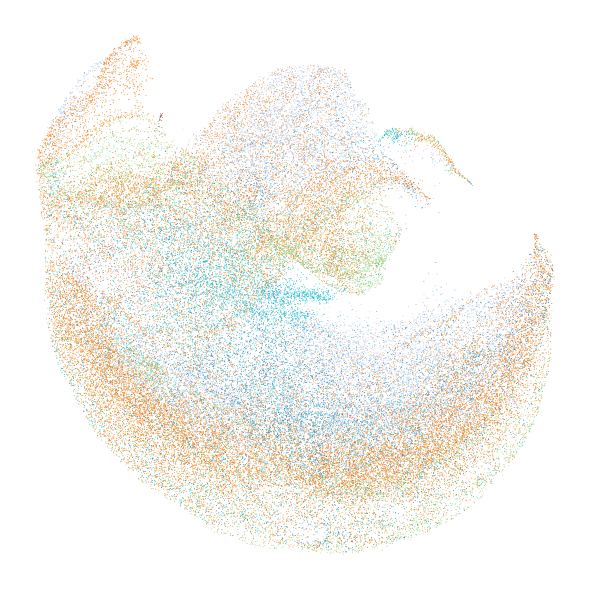

Generating plot for basis: umap_scvi...


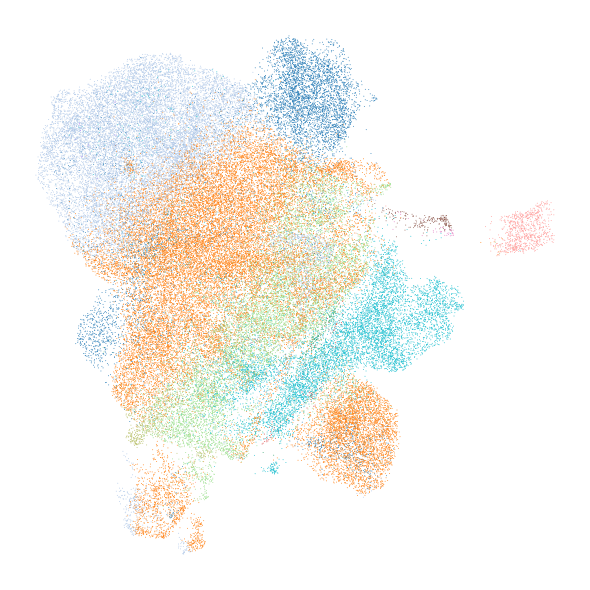

Generating plot for basis: umap_mrvi_u...


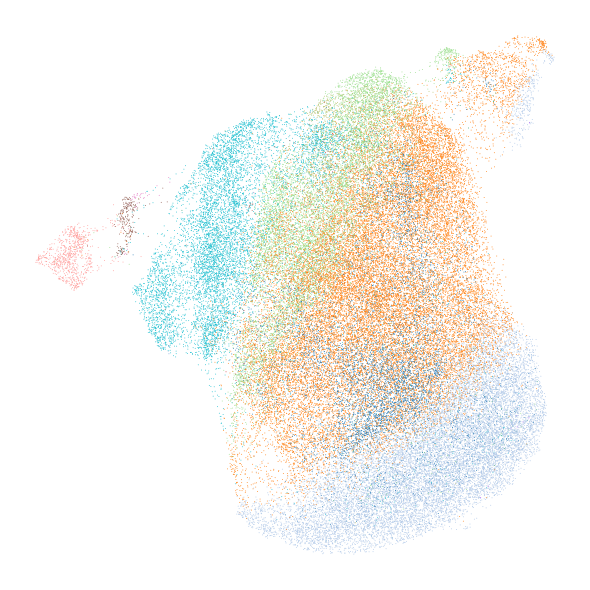

Generating plot for basis: umap_mrvi_z...


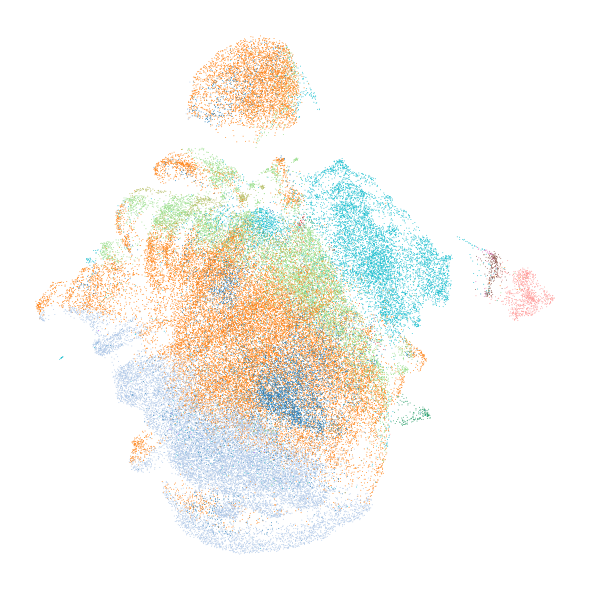

In [4]:
# Loop through each integration base method
for base in base_methods:
    current_basis = f"umap_{base}"

    # Print current status so you know what is rendering
    print(f"Generating plot for basis: {current_basis}...")

    # Set up a clean, single-plot figure for each method
    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot the embedding directly to the notebook cell
    sc.pl.embedding(
        adata,
        basis=current_basis,
        color="level_3_annot",
        ax=ax,
        show=False,  # Keep open for adjustments below
        legend_loc=None,  # Drops the legend
        title="",  # <--- Setting this to an empty string removes the Scanpy title
        frameon=False,
    )

    # Clean up plot aesthetics
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()

    # Force the notebook to display this specific plot before moving to the next iteration
    plt.show()
    plt.close(fig)

Generating plot for basis: umap_unintegrated...


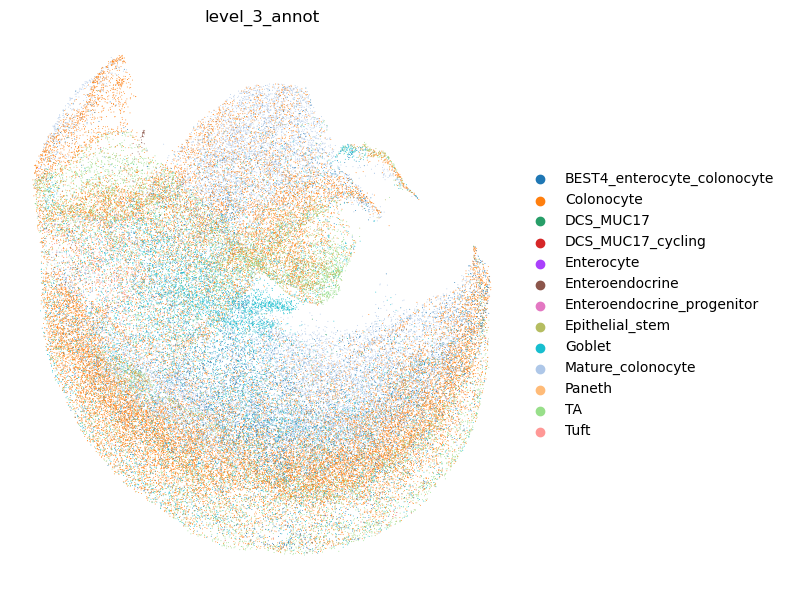

Generating plot for basis: umap_scvi...


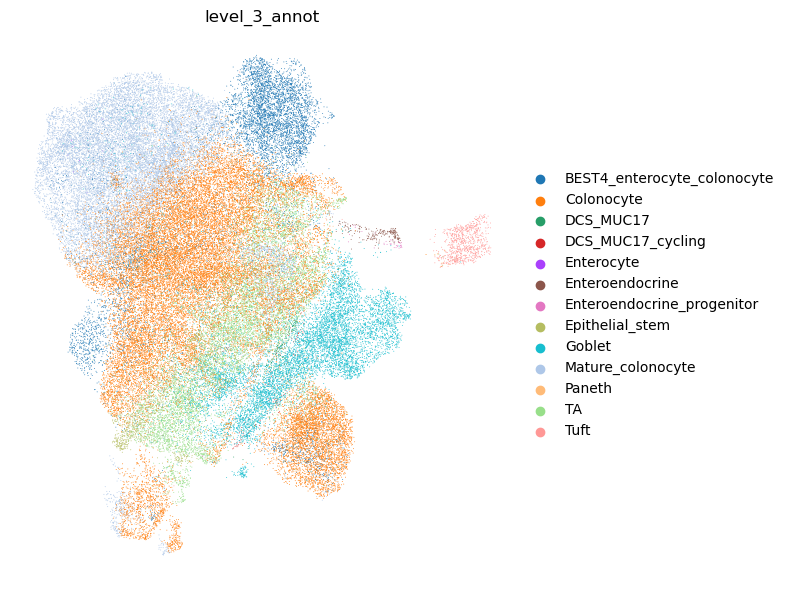

Generating plot for basis: umap_mrvi_u...


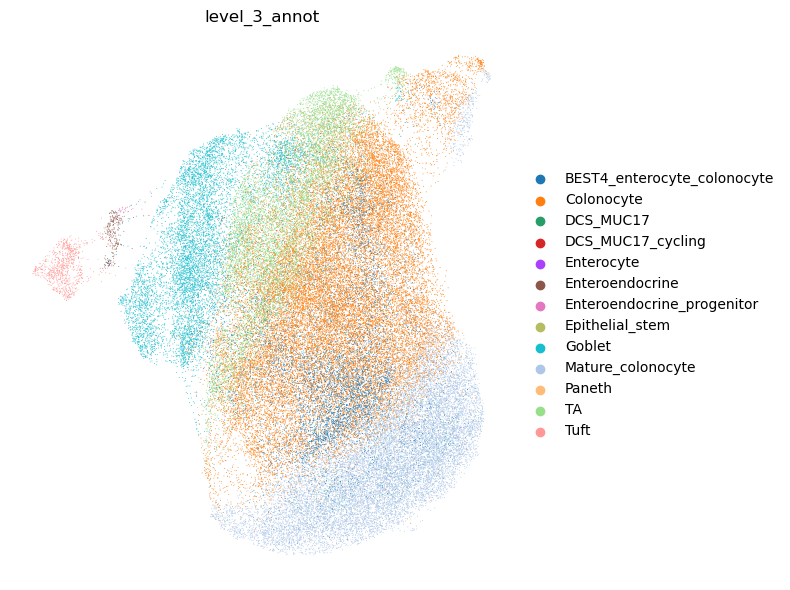

Generating plot for basis: umap_mrvi_z...


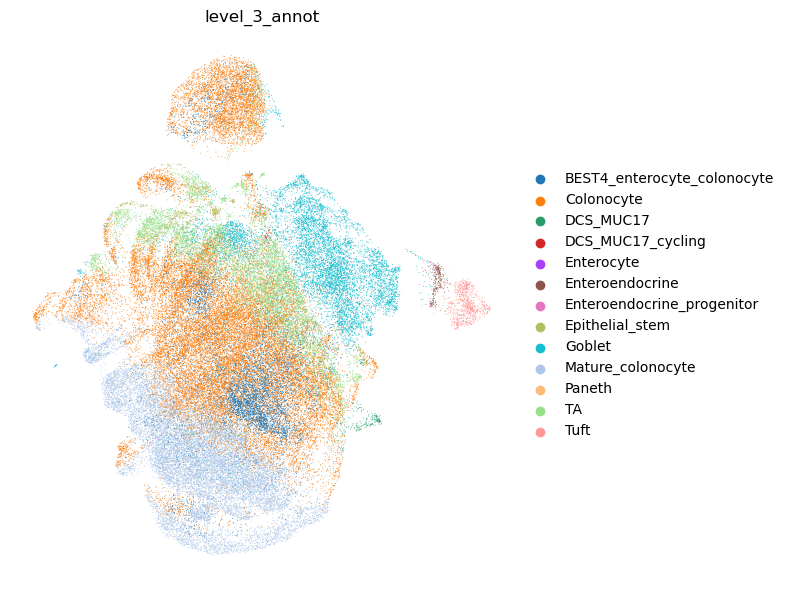

In [5]:
# Loop through each integration base method
for base in base_methods:
    current_basis = f"umap_{base}"

    # Print current status so you know what is rendering
    print(f"Generating plot for basis: {current_basis}...")

    # Set up a clean, single-plot figure for each method
    fig, ax = plt.subplots(figsize=(8, 6))  # Slightly widened to accommodate the legend gracefully

    # Plot the embedding directly to the notebook cell (With Labels & Legends restored)
    sc.pl.embedding(
        adata,
        basis=current_basis,
        color="level_3_annot",
        ax=ax,
        show=False,  
        legend_loc="right margin",  # Restores the cell type legend on the right margin
        frameon=False,
    )

    # Restoring axis labels dynamically based on the current basis
    ax.set_xlabel(f"{current_basis.upper()} 1")
    ax.set_ylabel(f"{current_basis.upper()} 2")

    plt.tight_layout()

    # Force the notebook to display this specific plot before moving to the next iteration
    plt.show()
    plt.close(fig)

In [ ]:
# Loop through each integration base method
for base in base_methods:
    current_basis = f"umap_{base}"

    # Print current status so you know what is rendering
    print(f"Generating plot for basis: {current_basis}...")

    # Set up a clean, single-plot figure for each method
    fig, ax = plt.subplots(figsize=(8, 6))  # Slightly widened to accommodate the legend gracefully

    # Plot the embedding directly to the notebook cell (With Labels & Legends restored)
    sc.pl.embedding(
        adata,
        basis=current_basis,
        color="level_3_annot",
        ax=ax,
        show=False,  
        legend_loc="right margin",  # Restores the cell type legend on the right margin
        frameon=False,
    )

    # Restoring axis labels dynamically based on the current basis
    ax.set_xlabel(f"{current_basis.upper()} 1")
    ax.set_ylabel(f"{current_basis.upper()} 2")

    plt.tight_layout()

    # Force the notebook to display this specific plot before moving to the next iteration
    plt.show()
    plt.close(fig)

In [ ]:
import time

distance_keys = [
    "unintegrated_distances", 
    "neighbors_scvi_distances", 
    "neighbors_mrvi_u_distances", 
    "neighbors_mrvi_z_distances"
]

biocons = BioConservation(isolated_labels=True)

start = time.time()
bm = Benchmarker(
    adata,
    batch_key="donorID_unified",
    label_key="level_3_annot",
    embedding_obsm_keys=["X_pca", "X_scvi", "X_mrvi_u", "X_mrvi_z"],
    pre_integrated_embedding_obsm_key="X_pca",
    bio_conservation_metrics=biocons,
    batch_correction_metrics=BatchCorrection(),
    n_jobs=-1,
)
#bm.prepare(neighbor_computer=faiss_brute_force_nn)
bm.benchmark()
end = time.time()
print(f"Time: {int((end - start) / 60)} min {int((end - start) % 60)} sec")

Embeddings:   0%|          | 0/4 [00:00<?, ?it/s]E0517 20:46:38.330099 1887794 slow_operation_alarm.cc:73] 
********************************
[Compiling module input_reduce_fusion for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0517 20:48:06.921534 1887786 slow_operation_alarm.cc:140] The operation took 3m28.591598366s

********************************
[Compiling module input_reduce_fusion for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


INFO     Enterocyte consists of a single batch or is too small. Skip.                                              
INFO     Paneth consists of a single batch or is too small. Skip.                                                  


/home/melrie/miniforge3/envs/hi/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings:  25%|██▌       | 1/4 [07:15<21:47, 435.79s/it]

INFO     Enterocyte consists of a single batch or is too small. Skip.                                              
INFO     Paneth consists of a single batch or is too small. Skip.                                                  


/home/melrie/miniforge3/envs/hi/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings:  50%|█████     | 2/4 [09:33<08:40, 260.34s/it]

INFO     Enterocyte consists of a single batch or is too small. Skip.                                              
INFO     Paneth consists of a single batch or is too small. Skip.                                                  


/home/melrie/miniforge3/envs/hi/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings:  75%|███████▌  | 3/4 [10:38<02:51, 171.10s/it]

INFO     Enterocyte consists of a single batch or is too small. Skip.                                              
INFO     Paneth consists of a single batch or is too small. Skip.                                                  


/home/melrie/miniforge3/envs/hi/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings: 100%|██████████| 4/4 [16:37<00:00, 249.33s/it]


Time: 20 min 48 sec


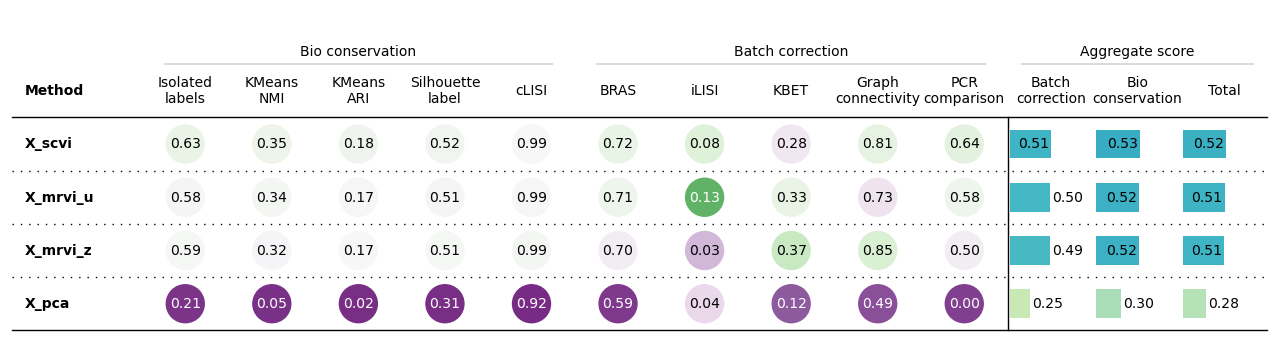

In [ ]:
bm.plot_results_table()